# Level 1 — Task 3: Basic Data Visualization
**Codveda Technology | Data Analytics Internship**

> **Dataset:** `1_iris.csv` | **Tools:** Python, matplotlib, seaborn
>
> **Objective:** Create bar plots, line charts, and scatter plots; customize labels, titles, and legends; export plots as images for reports.


## Step 1 — Imports and Setup

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.1)

plt.rcParams.update({
    "figure.dpi": 120
})

os.makedirs("outputs/level1/viz_plots", exist_ok=True)

df = pd.read_csv("1_iris.csv")

SPECIES_COLORS = {
    "setosa": "#4CAF50",
    "versicolor": "#2196F3",
    "virginica": "#FF5722"
}

FEATURES = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

print("Data loaded. Ready to plot.")

Data loaded. Ready to plot.


## Plot 1 — Bar Chart: Mean Petal Length by Species

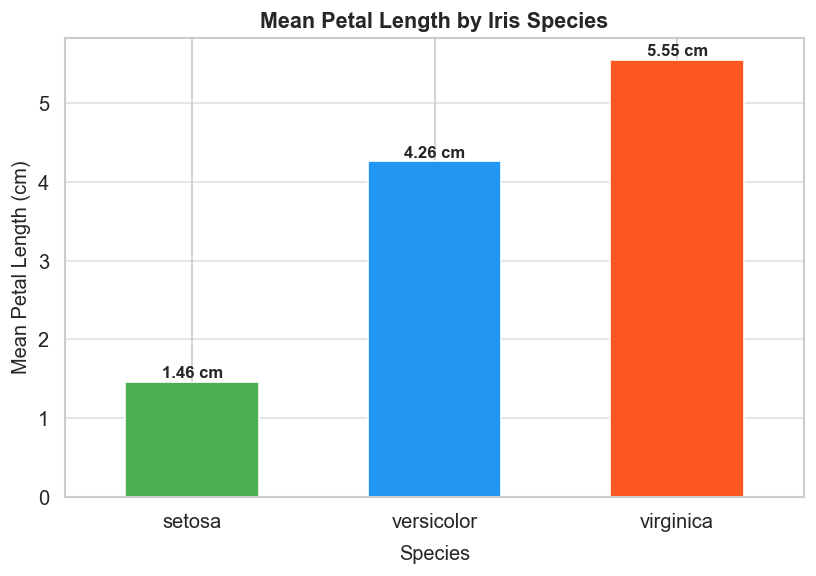

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
species_means = df.groupby("species")["petal_length"].mean().sort_values()
bars = species_means.plot(kind="bar", ax=ax,
                          color=[SPECIES_COLORS[s] for s in species_means.index],
                          edgecolor="white", width=0.55)

for i, val in enumerate(species_means):
    ax.text(i, val + 0.05, f"{val:.2f} cm", ha="center", fontsize=10, fontweight="bold")

ax.set_xlabel("Species", fontsize=12, labelpad=8)
ax.set_ylabel("Mean Petal Length (cm)", fontsize=12)
ax.set_title("Mean Petal Length by Iris Species", fontsize=13, fontweight="bold")
ax.tick_params(axis="x", rotation=0)
ax.yaxis.grid(True, alpha=0.6); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("outputs/level1/viz_plots/bar_petal_length.png")
plt.show()

## Plot 2 — Grouped Bar Chart: All Features by Species

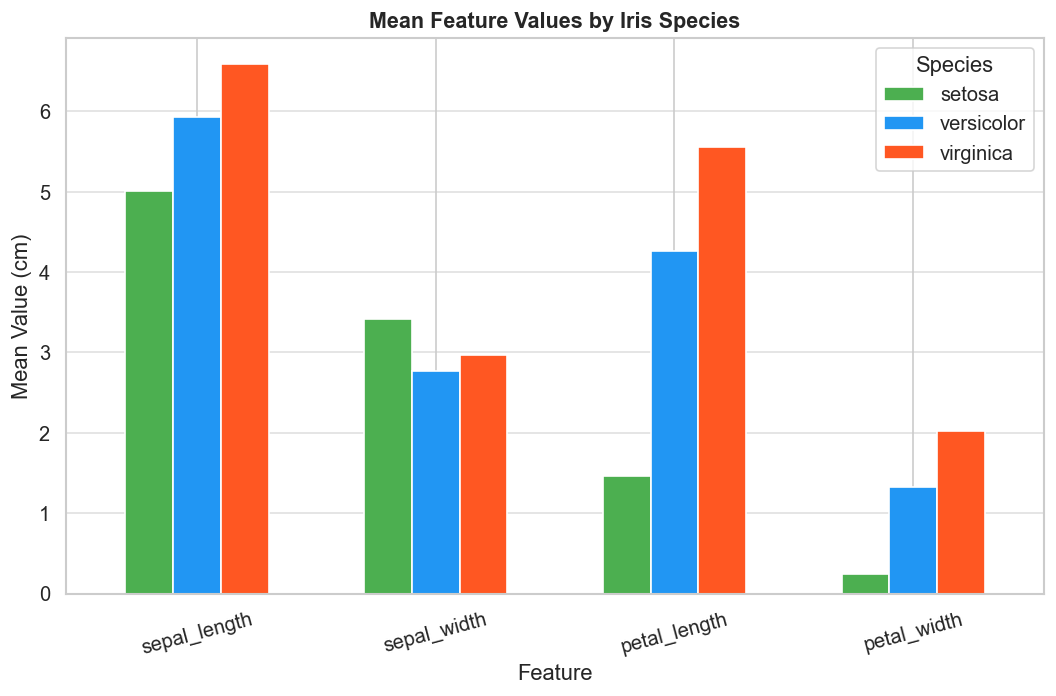

In [4]:
feature_means = df.groupby("species")[FEATURES].mean()

fig, ax = plt.subplots(figsize=(9, 6))
feature_means.T.plot(kind="bar", ax=ax,
                     color=list(SPECIES_COLORS.values()),
                     edgecolor="white", width=0.6)
ax.set_xlabel("Feature"); ax.set_ylabel("Mean Value (cm)")
ax.set_title("Mean Feature Values by Iris Species", fontsize=13, fontweight="bold")
ax.tick_params(axis="x", rotation=15)
ax.legend(title="Species"); ax.yaxis.grid(True, alpha=0.6); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("outputs/level1/viz_plots/bar_all_features.png")
plt.show()

## Plot 3 — Line Chart: Feature Profile Comparison

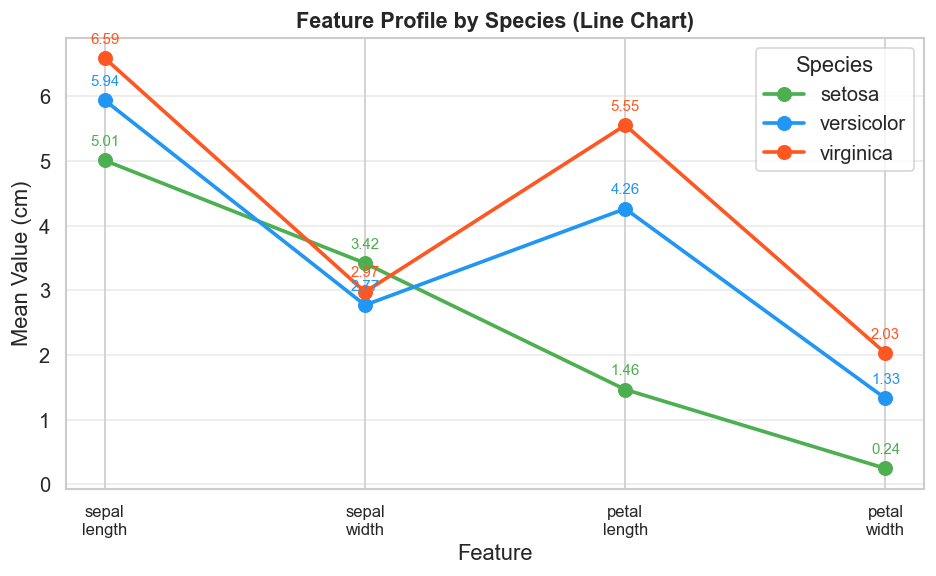

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(FEATURES))

for species, color in SPECIES_COLORS.items():
    means = df[df["species"] == species][FEATURES].mean().values
    ax.plot(x, means, marker="o", linewidth=2.2, markersize=8,
            label=species, color=color)
    for xi, yi in zip(x, means):
        ax.annotate(f"{yi:.2f}", (xi, yi), textcoords="offset points",
                    xytext=(0, 9), ha="center", fontsize=9, color=color)

ax.set_xticks(x)
ax.set_xticklabels([f.replace("_", "\n") for f in FEATURES], fontsize=10)
ax.set_xlabel("Feature"); ax.set_ylabel("Mean Value (cm)")
ax.set_title("Feature Profile by Species (Line Chart)", fontsize=13, fontweight="bold")
ax.legend(title="Species"); ax.yaxis.grid(True, alpha=0.4); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("outputs/level1/viz_plots/line_feature_profiles.png")
plt.show()

## Plot 4 — Scatter Plot: Sepal Width vs Petal Width

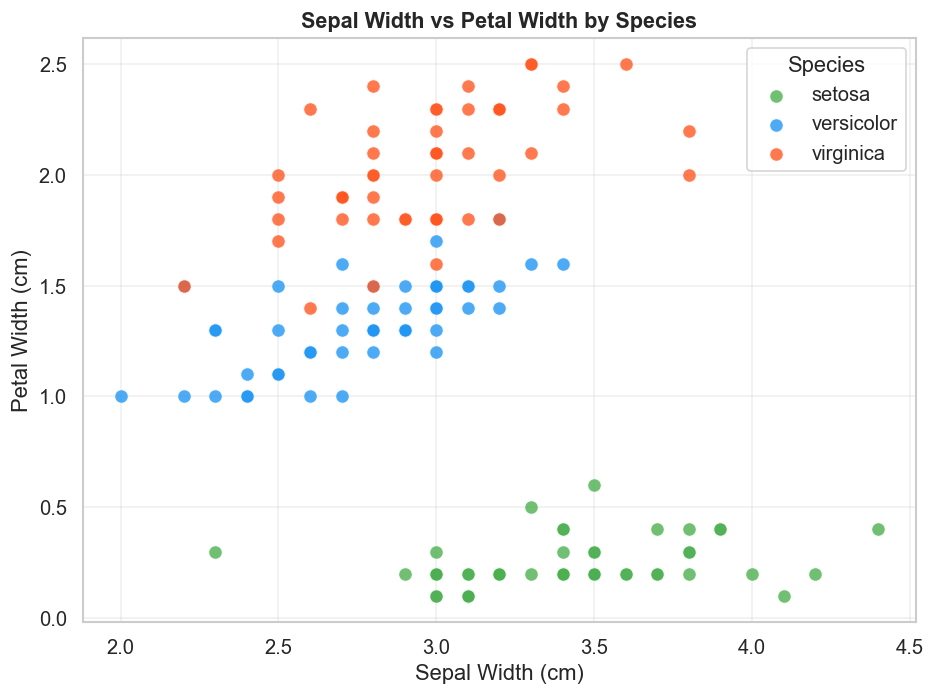

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
for species, color in SPECIES_COLORS.items():
    subset = df[df["species"] == species]
    ax.scatter(subset["sepal_width"], subset["petal_width"],
               label=species, color=color, s=65, alpha=0.8,
               edgecolors="white", linewidths=0.6)

ax.set_xlabel("Sepal Width (cm)"); ax.set_ylabel("Petal Width (cm)")
ax.set_title("Sepal Width vs Petal Width by Species", fontsize=13, fontweight="bold")
ax.legend(title="Species"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/level1/viz_plots/scatter_sepal_vs_petal.png")
plt.show()

## Plot 5 — Pie Chart: Species Distribution

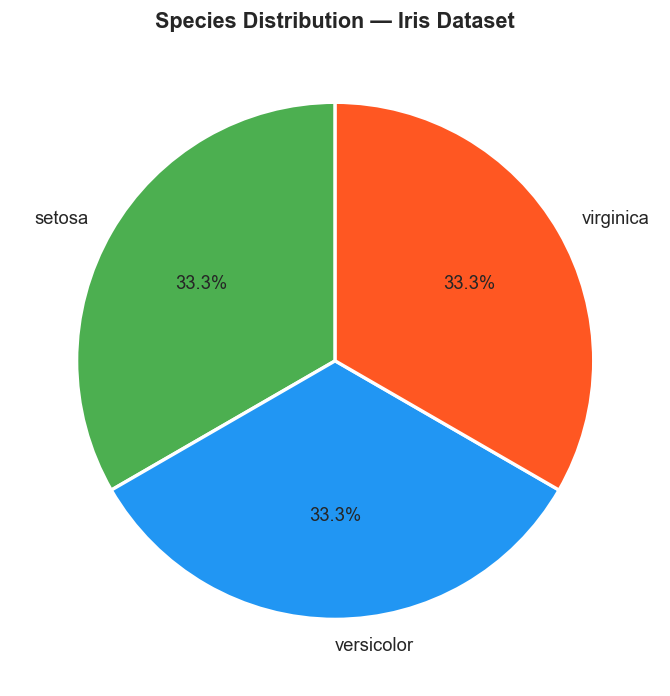

In [7]:
fig, ax = plt.subplots(figsize=(6, 6))
counts = df["species"].value_counts()
ax.pie(counts.values, labels=counts.index,
       colors=list(SPECIES_COLORS.values()),
       autopct="%1.1f%%", startangle=90,
       wedgeprops={"edgecolor": "white", "linewidth": 2},
       textprops={"fontsize": 11})
ax.set_title("Species Distribution — Iris Dataset", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/level1/viz_plots/pie_species_distribution.png")
plt.show()

## Plot 6 — Composite Report Figure (2×3 Grid)

> This is the plot to screenshot for your **LinkedIn post** — it shows all key visuals in one frame.

C:\Users\Ibrahim\AppData\Local\Temp\ipykernel_20496\666831356.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="species", y="petal_width", data=df, ax=ax,


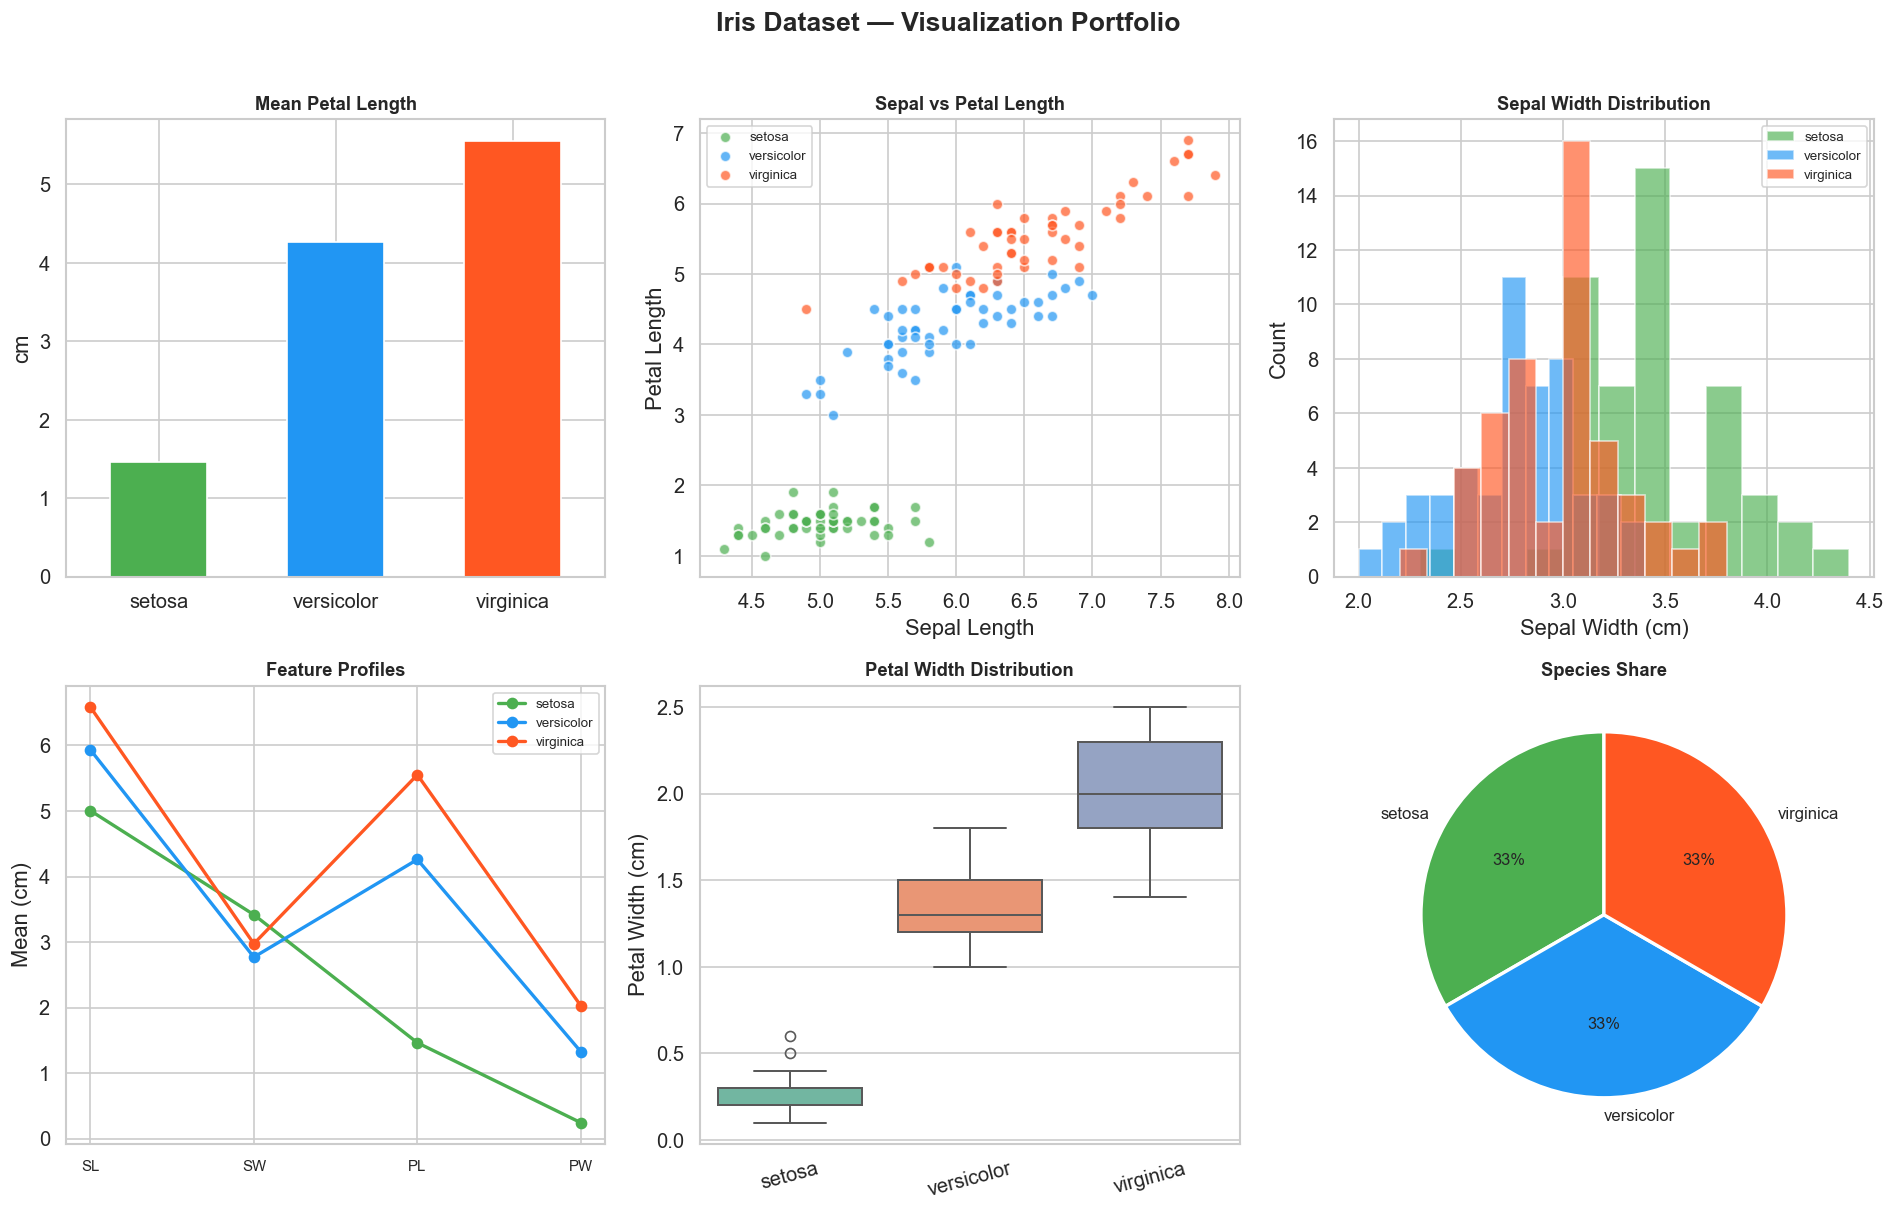

All plots saved to outputs/level1/viz_plots/


In [8]:
species_counts = df["species"].value_counts()
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Iris Dataset — Visualization Portfolio", fontsize=16, fontweight="bold", y=1.01)

# A — Bar
ax = axes[0, 0]
df.groupby("species")["petal_length"].mean().plot(
    kind="bar", ax=ax, color=list(SPECIES_COLORS.values()), edgecolor="white", width=0.55)
ax.set_title("Mean Petal Length", fontsize=11, fontweight="bold")
ax.set_xlabel(""); ax.tick_params(axis="x", rotation=0); ax.set_ylabel("cm")

# B — Scatter
ax = axes[0, 1]
for sp, color in SPECIES_COLORS.items():
    s = df[df["species"]==sp]
    ax.scatter(s["sepal_length"], s["petal_length"], color=color, s=40, alpha=0.7,
               label=sp, edgecolors="white")
ax.set_xlabel("Sepal Length"); ax.set_ylabel("Petal Length")
ax.set_title("Sepal vs Petal Length", fontsize=11, fontweight="bold"); ax.legend(fontsize=8)

# C — Histogram
ax = axes[0, 2]
for sp, color in SPECIES_COLORS.items():
    ax.hist(df[df["species"]==sp]["sepal_width"], bins=12, alpha=0.65,
            label=sp, color=color, edgecolor="white")
ax.set_xlabel("Sepal Width (cm)"); ax.set_ylabel("Count")
ax.set_title("Sepal Width Distribution", fontsize=11, fontweight="bold"); ax.legend(fontsize=8)

# D — Line
ax = axes[1, 0]
for sp, color in SPECIES_COLORS.items():
    means = df[df["species"]==sp][FEATURES].mean().values
    ax.plot(range(4), means, marker="o", lw=2, label=sp, color=color)
ax.set_xticks(range(4)); ax.set_xticklabels(["SL","SW","PL","PW"], fontsize=9)
ax.set_ylabel("Mean (cm)"); ax.set_title("Feature Profiles", fontsize=11, fontweight="bold")
ax.legend(fontsize=8)

# E — Boxplot
ax = axes[1, 1]
sns.boxplot(x="species", y="petal_width", data=df, ax=ax,
            palette="Set2", linewidth=1.2)
ax.set_xlabel(""); ax.tick_params(axis="x", rotation=15)
ax.set_ylabel("Petal Width (cm)"); ax.set_title("Petal Width Distribution", fontsize=11, fontweight="bold")

# F — Pie
ax = axes[1, 2]
ax.pie(species_counts.values, labels=species_counts.index,
       colors=list(SPECIES_COLORS.values()), autopct="%1.0f%%",
       startangle=90, wedgeprops={"edgecolor":"white","linewidth":2},
       textprops={"fontsize": 10})
ax.set_title("Species Share", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("outputs/level1/viz_plots/composite_report_figure.png", bbox_inches="tight")
plt.show()
print("All plots saved to outputs/level1/viz_plots/")